# NISAR Data Access & Exploration
### Group Meeting · 09 April, 2026

---

> **NASA-ISRO Synthetic Aperture Radar (NISAR)** is a joint Earth observation mission
> designed to measure surface deformation, ecosystem changes, ice dynamics, and natural hazards
> with unprecedented global coverage and consistency.

**Today we will:**
1. Understand what NISAR is and why it matters
2. See what data products are available
3. Search for data over our area of interest
4. Stream and visualize real NISAR data

---

**References:**
- NISAR Data User Guide: https://nisar-docs.asf.alaska.edu
- ASF DAAC: https://asf.alaska.edu
- Earthdata Search: https://search.earthdata.nasa.gov/search?q=nisar%20beta

---

## Part 1 · What is NISAR?

### The satellite

NISAR is a **Synthetic Aperture Radar (SAR)** satellite. It sends microwave pulses toward
the ground and measures the echo. Unlike optical satellites, SAR:
- Works through clouds and at night
- Measures surface properties that optical sensors cannot see
- Can detect millimetre-scale surface movement

NISAR carries **two radar frequencies**:
- **L-band** (24 cm wavelength): penetrates vegetation and snow, ideal for deformation
- **S-band** (12 cm wavelength): provided by ISRO, sensitive to surface scattering

### The orbit geometry

```
        ASCENDING pass                DESCENDING pass
        (S → N, looks west)           (N → S, looks east)

              ↑                              ↓
        ←  radar                        radar  →
              │                              │
         IDAHO                          IDAHO
```

- **Track**: the fixed ground path the satellite follows on every orbit.
  NISAR revisits the same track every **12 days**.
- **Frame**: a fixed spatial tile along the track. Frame 138 on Track 77 always
  covers the same patch of Idaho on every pass.
- **Ascending vs Descending**: the same area is observed from two different look
  directions. Combining both lets you separate vertical from horizontal displacement.

### InSAR

**Interferometric SAR (InSAR)** compares two radar images of the same area taken on
different dates. The phase difference between the two images is what we use to estimate snow depth changes.

```
Pass 1 (Dec 21)  ──────────────► radar image 1
                                        ↓
                              phase difference  →  surface displacement
                                        ↑
Pass 2 (Jan 2)   ──────────────► radar image 2

Temporal baseline = 12 days
```

Shorter baseline = better coherence = more reliable measurement.

---

## Part 2 · NISAR Data Products

NISAR produces a hierarchy of products from raw radar signal to analysis-ready geophysics. See the [Data Products Overview](https://nisar-docs.asf.alaska.edu/products-overview/).

| Product | Level | Type | What it is |
|---|---|---|---|
| **RSLC** | L1 | Single-pass | Raw focused radar image in range-Doppler coordinates |
| **GSLC** | L2 | Single-pass | Geocoded SLC — RSLC projected to map coordinates |
| **GCOV** | L2 | Single-pass | Backscatter covariance — like a calibrated radar image |
| **RIFG** | L1 | Pair | Wrapped interferogram in radar coordinates |
| **RUNW** | L1 | Pair | Unwrapped interferogram in radar coordinates |
| **GUNW** | L2 | Pair | **Geocoded unwrapped interferogram — our focus today** |
| **SME2** | L3 | Derived | Soil moisture |

### The GUNW product

The **Geocoded Unwrapped Interferogram (GUNW)** is NISAR's most complete InSAR product.
It is fully processed, coregistered, filtered, unwrapped, and geocoded to UTM.
One GUNW file represents the surface change between **two passes** of the same track.

| Layer | Resolution | What it tells you |
|---|---|---|
| Unwrapped phase | 20m | Surface displacement in radians |
| Coherence | 20m | Reliability of the phase (0 = noise, 1 = perfect) |
| Incidence angle | coarse | Radar look angle — needed to convert to vertical displacement |

### ⚠ Important: Beta products

All current NISAR products are **pre-calibration Beta**. They are excellent for:
- Building and testing workflows
- Early science exploration
- Learning the data format

Fully calibrated products are expected around **June 2026**.

---

## Part 3 · Setup

Everything we need today:

In [1]:
# All standard — no surprises
import asf_search as asf        # search the ASF catalog
import earthaccess               # authenticate with NASA Earthdata
import h5py                      # read HDF5 files
import numpy as np               # array math
import rioxarray                 # geospatial arrays + GeoTIFF export
import xarray as xr              # labeled arrays
import matplotlib.pyplot as plt  # plotting
from datetime import datetime
import geopandas as gpd
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

print("✓ All imports OK")
print(f"  asf_search version: {asf.__version__}")

✓ All imports OK
  asf_search version: 12.0.6


---

## Part 4 · Searching for Data

We use `asf_search`, a Python package from the Alaska Satellite Facility
that wraps the ASF Search API.

Key search parameters for NISAR:
- `dataset='NISAR'` — scope to NISAR only
- `processingLevel='GUNW'` — the product type we want
- `relativeOrbit=77` — track 77

> **Note:** Unlike UAVSAR (which uses campaign names), NISAR is searched
> by track, frame, and date range — it is a systematic global mission.

In [2]:
# ── Helper: parse interferometric pair dates from GUNW scene name ──
def parse_gunw_dates(scene_name):
    """
    GUNW filenames encode the reference and secondary acquisition dates.
    Example: ...20251221T135101...20260102T135101...
             ↑ reference (Dec 21)   ↑ secondary (Jan 2)
    """
    parts = scene_name.split('_')
    timestamps = [p for p in parts if len(p) == 15 and 'T' in p]
    if len(timestamps) >= 4:
        return timestamps[0][:8], timestamps[2][:8]
    return None, None

def temporal_baseline(scene_name):
    ref, sec = parse_gunw_dates(scene_name)
    if ref and sec:
        return abs((datetime.strptime(sec,'%Y%m%d') -
                    datetime.strptime(ref,'%Y%m%d')).days)
    return None

print("Helper functions defined.")

Helper functions defined.


### Search with Track Number

In [3]:
# Search for NISAR GUNW data on Track 77
print("Searching ASF catalog for NISAR GUNW on Track 77...")

results = asf.search(
    dataset         = 'NISAR',
    processingLevel = 'GUNW',
    relativeOrbit   = 77,
    maxResults      = 500,
)

print(f"\nFound {len(results)} granules on Track 77")

# What dates are available?
dates = sorted(set(
    parse_gunw_dates(r.properties['sceneName'])[0]
    for r in results
    if parse_gunw_dates(r.properties['sceneName'])[0]
))

print(f"\nReference dates available ({len(dates)} unique):")
for d in dates:
    fmt = f"{d[:4]}-{d[4:6]}-{d[6:]}"
    print(f"  {fmt}")

Searching ASF catalog for NISAR GUNW on Track 77...

Found 133 granules on Track 77

Reference dates available (5 unique):
  2025-11-03
  2025-11-15
  2025-11-27
  2025-12-09
  2025-12-21


### Search with Shapefile Geometry

In [4]:
mores_creek = gpd.read_file('../shape_files/Mores/mores_boundary.shp')
wkt = mores_creek.to_crs('EPSG:4326').geometry.unary_union.wkt

results = asf.search(
    dataset        = 'NISAR',
    processingLevel= 'GUNW',
    intersectsWith = wkt,
    maxResults     = 500,
)

print(f"\n Found {len(results)} granules intersecting Mores Creek boundary\n")

# Summarize unique track + frame + direction combinations
from collections import defaultdict
coverage = defaultdict(set)

for r in results:
    p   = r.properties
    ref, sec = parse_gunw_dates(p['sceneName'])
    key = (p.get('pathNumber'), p.get('frameNumber'), p.get('flightDirection'))
    if ref:
        coverage[key].add(ref)

print(f"{'Track':<8} {'Frame':<8} {'Direction':<14} {'Dates available'}")
print("-" * 55)
for (track, frame, direction), dates in sorted(coverage.items()):
    date_list = ', '.join(
        f"{d[:4]}-{d[4:6]}-{d[6:]}"
        for d in sorted(dates)
    )
    print(f"{str(track):<8} {str(frame):<8} {str(direction):<14} {date_list}")

["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 55787 simplified to 6 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]



 Found 9 granules intersecting Mores Creek boundary

Track    Frame    Direction      Dates available
-------------------------------------------------------
77       24       ASCENDING      2025-11-03, 2025-11-15, 2025-12-09
114      66       DESCENDING     2025-11-30, 2025-12-24
149      24       ASCENDING      2025-11-08, 2025-11-20, 2025-12-02, 2026-01-07


<Axes: >

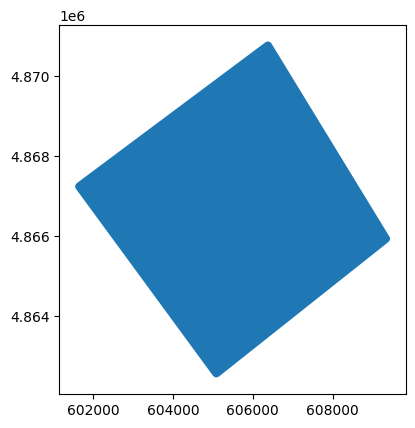

In [5]:
mores_creek.plot()

In [6]:
# results[0].properties

In [7]:
# How are the temporal baselines distributed?
from collections import Counter

baselines = [
    temporal_baseline(r.properties['sceneName'])
    for r in results
    if temporal_baseline(r.properties['sceneName'])
]
counts = Counter(baselines)

print("Temporal baseline distribution:")
print(f"  {'Baseline':>12}   {'Granules':>10}   Notes")
print("  " + "-" * 50)
notes = {12: '✓ Ideal', 24: '⚠ Acceptable', 48: '✗ High decorrelation risk'}
for days, count in sorted(counts.items()):
    print(f"  {days:>10}d   {count:>10}   {notes.get(days,'')}")

print(f"\n→ We will use the 12-day pairs — shortest baseline, best coherence.")

Temporal baseline distribution:
      Baseline     Granules   Notes
  --------------------------------------------------
          12d            5   ✓ Ideal
          24d            3   ⚠ Acceptable
          36d            1   

→ We will use the 12-day pairs — shortest baseline, best coherence.


In [8]:
# Filter to Frame 24 — the spatial tile covering our area of interest
# Filter to 12-day pairs — best coherence
frame138 = [
    r for r in results
    if r.properties.get('frameNumber') == 24
    and temporal_baseline(r.properties['sceneName']) == 12
]

print(f"Frame 24 · 12-day pairs: {len(frame138)} granules\n")
print(f"  {'Reference':<12} {'Secondary':<12} {'Direction':<12} {'BW (MHz)'}")
print("  " + "-" * 50)
for r in frame138:
    p = r.properties
    ref, sec = parse_gunw_dates(p['sceneName'])
    ref_fmt  = f"{ref[:4]}-{ref[4:6]}-{ref[6:]}"
    sec_fmt  = f"{sec[:4]}-{sec[4:6]}-{sec[6:]}"
    print(f"  {ref_fmt:<12} {sec_fmt:<12} {p.get('flightDirection',''):<12} {(p.get('rangeBandwidth') or ['?'])[0]}")

Frame 24 · 12-day pairs: 5 granules

  Reference    Secondary    Direction    BW (MHz)
  --------------------------------------------------
  2026-01-07   2026-01-19   ASCENDING    40
  2025-12-09   2025-12-21   ASCENDING    40
  2025-11-20   2025-12-02   ASCENDING    40
  2025-11-08   2025-11-20   ASCENDING    40
  2025-11-03   2025-11-15   ASCENDING    40


BW = Bandwidth: the range of radar frequencies used during acquisition, measured in MHz. Higher bandwidth = finer range resolution

In [9]:
# Select one granule — ascending, 40 MHz, full coverage
granule = next(
    r for r in frame138
    if r.properties.get('flightDirection') == 'ASCENDING'
    and r.properties.get('frameCoverage') == 'Full'
)
p = granule.properties
ref, sec = parse_gunw_dates(p['sceneName'])
bl = temporal_baseline(p['sceneName'])
ref_fmt = f"{ref[:4]}-{ref[4:6]}-{ref[6:]}"
sec_fmt = f"{sec[:4]}-{sec[4:6]}-{sec[6:]}"

print("Selected granule:")
print(f"  Scene      : {p['sceneName'][:70]}...")
print(f"  Track      : {p.get('pathNumber')}  — fixed ground path, 12-day repeat")
print(f"  Frame      : {p.get('frameNumber')}  — spatial tile covering Idaho")
print(f"  Direction  : {p.get('flightDirection')}  — satellite flying S→N, looking west")
print(f"  Reference  : {ref_fmt}")
print(f"  Secondary  : {sec_fmt}")
print(f"  Baseline   : {bl} days")
print(f"  Coverage   : {p.get('frameCoverage')}")
print(f"  File size  : {p.get('bytes',{}).get(p.get('fileName',''),{}).get('bytes',0)/1e9:.2f} GB on disk (compressed HDF5)")

Selected granule:
  Scene      : NISAR_L2_PR_GUNW_009_149_A_024_010_4000_SH_20260107T123757_20260107T12...
  Track      : 149  — fixed ground path, 12-day repeat
  Frame      : 24  — spatial tile covering Idaho
  Direction  : ASCENDING  — satellite flying S→N, looking west
  Reference  : 2026-01-07
  Secondary  : 2026-01-19
  Baseline   : 12 days
  Coverage   : Full
  File size  : 2.44 GB on disk (compressed HDF5)


Full = the granule covers the entire frame tile end to end

---

## Part 5 · Accessing the Data

### Two ways to get NISAR data

| | Download | Stream |
|---|---|---|
| What happens | Full 2.45 GB file saved to disk | Only the layers you request are fetched |
| Disk usage | 2.45 GB | None — file never saved |
| RAM usage | Same | Same |
| Speed (first read) | Slower (download first) | Faster to start |
| Speed (repeated reads) | Fast (local disk) | Slower (re-fetches each time) |
| Best for | Repeated analysis of same file | Exploration across many granules |

> **Key insight:** RAM footprint is the same either way.
> Streaming saves **disk space**, not RAM.
> Reading a layer from a local HDF5 uses the same RAM as streaming it.

### Why not S3?

NISAR data lives in AWS S3 `us-west-2` (Oregon). Direct S3 access requires your
compute to be **inside** AWS `us-west-2`. From a local machine anywhere else,
HTTPS streaming via CloudFront is the correct protocol — and it works from anywhere.

### Authentication

A free [NASA Earthdata Login](https://urs.earthdata.nasa.gov) account is required.
`earthaccess` handles the authentication and opens an HTTPS session for us.

In [10]:
# Authenticate with NASA Earthdata
# Uses .netrc if configured, otherwise prompts for username + password
auth = earthaccess.login()
print(f"Authenticated: {auth.authenticated}")

Authenticated: True


In [11]:
# Open HTTPS stream — no data transferred yet
# The URL follows a predictable pattern from the scene name
BASE_URL   = 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_BETA_V1'
scene_name = p['sceneName']
https_url  = f"{BASE_URL}/{scene_name}/{scene_name}.h5"

# Verify it matches what asf_search gives us
assert https_url == p['url'], "URL mismatch"

print("Opening HTTPS stream...")
fs = earthaccess.get_fsspec_https_session()
hf = h5py.File(
    fs.open(https_url, cache_type='background', block_size=16*1024*1024),
    'r'
)
print(f"✓ Stream open")
print(f"  Top-level groups: {list(hf.keys())}")
print(f"  No data transferred yet — the file is 2.45 GB on disk but nothing has moved.")

Opening HTTPS stream...
✓ Stream open
  Top-level groups: ['complex64', 'science']
  No data transferred yet — the file is 2.45 GB on disk but nothing has moved.


---

## Part 6 · Inside the HDF5 File

NISAR uses HDF5 — a hierarchical file format. Think of it like a file system
inside a file: groups (folders) contain datasets (arrays).

The GUNW structure we care about:
```
/science/LSAR/GUNW/
├── grids/frequencyA/
│   ├── unwrappedInterferogram/HH/
│   │   ├── unwrappedPhase      ← surface displacement in radians (20m)
│   │   ├── coherenceMagnitude  ← phase reliability 0–1 (20m)
│   │   └── xCoordinates, yCoordinates
│   └── wrappedInterferogram/HH/
│       └── wrappedInterferogram ← complex array — amplitude + wrapped phase (5m)
└── metadata/
    └── radarGrid/
        └── incidenceAngle      ← radar look angle (coarse grid)
```

In [12]:
BASE_GRIDS = 'science/LSAR/GUNW/grids/frequencyA'
BASE_META  = 'science/LSAR/GUNW/metadata'

# Read coordinate arrays — these are tiny, just 1D arrays
x_20m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/xCoordinates'][:]
y_20m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/yCoordinates'][:]
x_inc  = hf[f'{BASE_META}/radarGrid/xCoordinates'][:]
y_inc  = hf[f'{BASE_META}/radarGrid/yCoordinates'][:]
epsg   = int(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/projection'][()])

print(f"Projection     : EPSG:{epsg}  (UTM — Universal Transverse Mercator)")
print(f"20m grid       : {len(x_20m)} cols × {len(y_20m)} rows")
print(f"Width          : {(x_20m.max()-x_20m.min())/1000:.0f} km")
print(f"Height         : {abs(y_20m.max()-y_20m.min())/1000:.0f} km")
print(f"Easting        : {x_20m.min():.0f} – {x_20m.max():.0f} m")
print(f"Northing       : {y_20m.min():.0f} – {y_20m.max():.0f} m")

Projection     : EPSG:32611  (UTM — Universal Transverse Mercator)
20m grid       : 4536 cols × 4491 rows
Width          : 363 km
Height         : 359 km
Easting        : 488200 – 851000 m
Northing       : 4747000 – 5106200 m


---

## Part 7 · Reading the Layers

This is the moment data actually transfers over the network.
We request only the 20m layers — the most useful for deformation analysis
and far more memory-efficient than the 5m layers.

### Disk vs RAM — an important distinction

The HDF5 file is stored **compressed** on NASA's server (2.36 GB on disk).
When we read a layer, h5py decompresses it into a numpy array in RAM.
The RAM footprint is determined by the **uncompressed array size**, not the disk size:

```
RAM footprint = rows × cols × bytes_per_element

unwrapped phase: 4716 × 4635 × 4 bytes = 88 MB in RAM
```

Reading from a local downloaded file gives the **same RAM footprint** as streaming.
Streaming saves disk space, not RAM.

In [13]:
def read_masked(ds_path):
    """Read an HDF5 dataset, mask fill values and zeros (no-data)."""
    ds   = hf[ds_path]
    data = ds[:].astype(np.float32)
    fv   = ds.attrs.get('_FillValue', None)
    if fv is not None:
        data = np.where(data == fv, np.nan, data)
    data[data == 0] = np.nan
    return data

def make_da(data, x_coords, y_coords, name, long_name, units):
    """Wrap a numpy array in a georeferenced xarray DataArray."""
    da = xr.DataArray(
        data, dims=['y', 'x'],
        coords={'x': x_coords, 'y': y_coords},
        name=name,
        attrs={'long_name': long_name, 'units': units}
    )
    da = da.rio.write_crs(f'EPSG:{epsg}')
    da = da.rio.write_nodata(np.nan)
    return da

print("Reading 20m layers...")
print("(Data transfers from NASA servers now)\n")

# ── Unwrapped phase ──
print("  Reading unwrapped phase...")
unwrapped = read_masked(f'{BASE_GRIDS}/unwrappedInterferogram/HH/unwrappedPhase')
print(f"  Shape: {unwrapped.shape}  RAM: {unwrapped.nbytes/1e6:.0f} MB  Range: {np.nanmin(unwrapped):.1f} – {np.nanmax(unwrapped):.1f} rad")

# ── Coherence ──
print("  Reading coherence...")
coherence = read_masked(f'{BASE_GRIDS}/unwrappedInterferogram/HH/coherenceMagnitude')
print(f"  Shape: {coherence.shape}  RAM: {coherence.nbytes/1e6:.0f} MB  Range: {np.nanmin(coherence):.3f} – {np.nanmax(coherence):.3f}")

# ── Incidence angle ──
print("  Reading incidence angle...")
heights   = hf[f'{BASE_META}/radarGrid/heightAboveEllipsoid'][:]
gidx      = int(np.argmin(np.abs(heights)))
incidence = hf[f'{BASE_META}/radarGrid/incidenceAngle'][gidx].astype(np.float32)
incidence[incidence == 0] = np.nan
print(f"  Shape: {incidence.shape}  RAM: {incidence.nbytes/1e6:.1f} MB  Range: {np.nanmin(incidence):.1f}° – {np.nanmax(incidence):.1f}°")

# ── Close stream ──
hf.close()

# ── RAM summary (full frame) ──
layers = {'unwrapped_phase': unwrapped, 'coherence': coherence, 'incidence_angle': incidence}
total  = sum(a.nbytes for a in layers.values())
print(f"\n── RAM Footprint (full frame) ──────────────────")
for name, arr in layers.items():
    print(f"  {name:<25} {arr.nbytes/1e6:6.0f} MB")
print(f"  {'Total':<25} {total/1e6:6.0f} MB")
print(f"\n  Full HDF5 on disk (compressed): 2,357 MB")
print(f"  These 3 layers in RAM         : {total/1e6:.0f} MB")
print(f"\n  Note: disk (compressed) ≠ RAM (uncompressed)")
print(f"  Streaming saves disk space, not RAM.")
print(f"\n✓ Stream closed. Full frame in memory.")

# ─────────────────────────────────────────────────────────────────────────────
# CLIP TO MORES CREEK BOUNDARY
# The search used the shapefile to find the right granule, but what we received
# is the entire Frame 24. We now clip to the exact Mores Creek boundary.
# RAM during clipping: still the full frame — clipping happens after reading.
# The clipped arrays and GeoTIFFs will be much smaller.
# ─────────────────────────────────────────────────────────────────────────────
print("\nClipping to Mores Creek boundary...")

# Load shapefile and reproject to match the data CRS (UTM)
mores_creek = gpd.read_file('../shape_files/Mores/mores_boundary.shp')

# Wrap full-frame arrays in georeferenced DataArrays
da_unwrapped = make_da(unwrapped, x_20m, y_20m,
                        'unwrapped_phase', 'Unwrapped interferometric phase', 'radians')
da_coherence = make_da(coherence, x_20m, y_20m,
                        'coherence', 'Interferometric coherence magnitude', '0-1')
da_incidence = make_da(incidence, x_inc, y_inc,
                        'incidence_angle', 'Radar incidence angle', 'degrees')

# Reproject shapefile to match data CRS
mores_utm = mores_creek.to_crs(da_unwrapped.rio.crs)

# Clip each layer to the exact polygon boundary
geometries = mores_utm.geometry.values

unwrapped_clip = da_unwrapped.rio.clip(geometries, all_touched=True, drop=True)
coherence_clip = da_coherence.rio.clip(geometries, all_touched=True, drop=True)
incidence_clip = da_incidence.rio.clip(geometries, all_touched=True, drop=True)

# # Clip each layer to the exact polygon boundary
# clip_kw = dict(geometry=mores_utm.geometry, all_touched=True, drop=True)
# unwrapped_clip = da_unwrapped.rio.clip(**clip_kw)
# coherence_clip = da_coherence.rio.clip(**clip_kw)
# incidence_clip = da_incidence.rio.clip(**clip_kw)

print(f"  Full frame shape  : {unwrapped.shape}")
print(f"  Clipped shape     : {unwrapped_clip.shape}")
print(f"  Clipped extent    : {unwrapped_clip.rio.bounds()}")

# RAM comparison
clip_ram = (unwrapped_clip.nbytes + coherence_clip.nbytes + incidence_clip.nbytes) / 1e6
print(f"\n  Full frame RAM    : {total/1e6:.0f} MB")
print(f"  Clipped RAM       : {clip_ram:.1f} MB")
print(f"\n✓ Clipped to Mores Creek. Ready to export and plot.")

Reading 20m layers...
(Data transfers from NASA servers now)

  Reading unwrapped phase...
  Shape: (4491, 4536)  RAM: 81 MB  Range: -9.9 – 19.4 rad
  Reading coherence...
  Shape: (4491, 4536)  RAM: 81 MB  Range: 0.003 – 0.989
  Reading incidence angle...
  Shape: (731, 738)  RAM: 2.2 MB  Range: 26.6° – 52.3°

── RAM Footprint (full frame) ──────────────────
  unwrapped_phase               81 MB
  coherence                     81 MB
  incidence_angle                2 MB
  Total                        165 MB

  Full HDF5 on disk (compressed): 2,357 MB
  These 3 layers in RAM         : 165 MB

  Note: disk (compressed) ≠ RAM (uncompressed)
  Streaming saves disk space, not RAM.

✓ Stream closed. Full frame in memory.

Clipping to Mores Creek boundary...
  Full frame shape  : (4491, 4536)
  Clipped shape     : (106, 99)
  Clipped extent    : (601520.0, 4862400.0, 609440.0, 4870880.0)

  Full frame RAM    : 165 MB
  Clipped RAM       : 0.1 MB

✓ Clipped to Mores Creek. Ready to export and

---

## Part 8 · Visualization

Let's look at what we have. Three panels:

1. **Unwrapped phase** — the deformation signal in radians
2. **Coherence** — where can we trust the phase?
3. **Incidence angle** — the radar look geometry across the swath

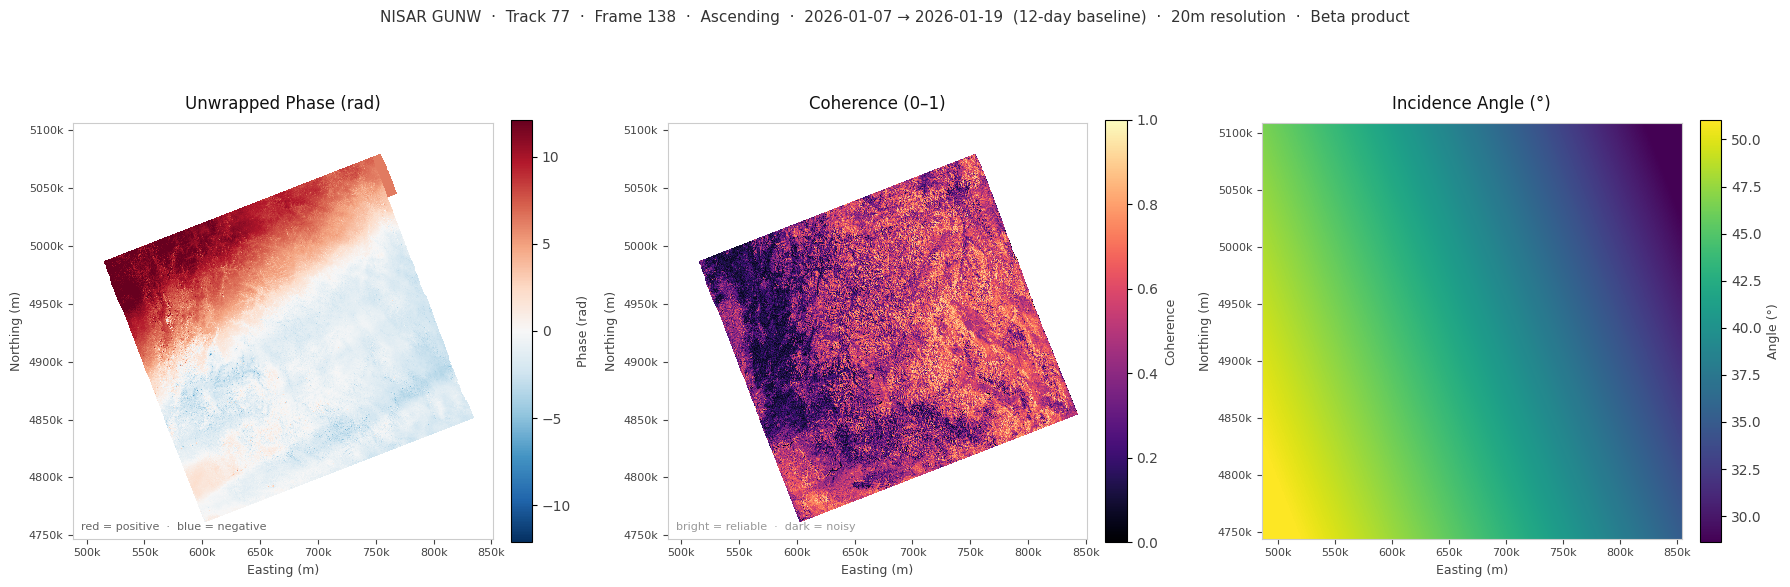

Saved: nisar_gunw_presentation.png


In [14]:
def pct_limits(data, lo=2, hi=98):
    valid = data[np.isfinite(data)]
    return float(np.percentile(valid, lo)), float(np.percentile(valid, hi))

ext_20m = [x_20m.min(), x_20m.max(), y_20m.min(), y_20m.max()]
ext_inc = [x_inc.min(), x_inc.max(), y_inc.min(), y_inc.max()]
imkw    = dict(origin='upper', aspect='equal', interpolation='nearest')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

def style_ax(ax, title):
    ax.set_facecolor('white')
    ax.set_title(title, color='#111111', fontsize=12, fontweight='normal', pad=10)
    ax.set_xlabel('Easting (m)', color='#444444', fontsize=9)
    ax.set_ylabel('Northing (m)', color='#444444', fontsize=9)
    ax.tick_params(colors='#444444', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y/1e3:.0f}k'))

def add_cbar(fig, im, ax, label):
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label, color='#444444', fontsize=9)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#444444')

# ── Unwrapped phase ──
ax = axes[0]
vmin, vmax = pct_limits(unwrapped)
lim = max(abs(vmin), abs(vmax))
im  = ax.imshow(unwrapped, extent=ext_20m, cmap='RdBu_r', vmin=-lim, vmax=lim, **imkw)
style_ax(ax, 'Unwrapped Phase (rad)')
add_cbar(fig, im, ax, 'Phase (rad)')
ax.text(0.02, 0.02, 'red = positive  ·  blue = negative',
        transform=ax.transAxes, color='#666666', fontsize=8)

# ── Coherence ──
ax = axes[1]
im  = ax.imshow(coherence, extent=ext_20m, cmap='magma', vmin=0, vmax=1, **imkw)
style_ax(ax, 'Coherence (0–1)')
add_cbar(fig, im, ax, 'Coherence')
ax.text(0.02, 0.02, 'bright = reliable  ·  dark = noisy',
        transform=ax.transAxes, color='#999999', fontsize=8)

# ── Incidence angle ──
ax = axes[2]
vmin, vmax = pct_limits(incidence, 1, 99)
im  = ax.imshow(incidence, extent=ext_inc, cmap='viridis', vmin=vmin, vmax=vmax, **imkw)
style_ax(ax, 'Incidence Angle (°)')
add_cbar(fig, im, ax, 'Angle (°)')

fig.suptitle(
    f'NISAR GUNW  ·  Track 77  ·  Frame 138  ·  Ascending  ·  '
    f'{ref_fmt} → {sec_fmt}  ({bl}-day baseline)  ·  20m resolution  ·  Beta product',
    fontsize=11, color='#333333', y=1.01
)
plt.tight_layout()
plt.savefig('nisar_gunw_presentation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: nisar_gunw_presentation.png")

---

## Part 9 · Export to GeoTIFF

GeoTIFFs are the standard format for geospatial rasters.
They embed the coordinate reference system and spatial extent directly in the file,
making them immediately usable in QGIS, ArcGIS, or any GIS tool.

We save our three core layers — the HDF5 never touches disk.

In [ ]:
OUT_DIR = Path(f'./nisar_geotiff/track77_frame138_{ref}_{sec}')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def make_da(data, x_coords, y_coords, name, long_name, units):
    """Wrap a numpy array in a georeferenced xarray DataArray."""
    da = xr.DataArray(
        data, dims=['y','x'],
        coords={'x': x_coords, 'y': y_coords},
        name=name,
        attrs={'long_name': long_name, 'units': units}
    )
    da = da.rio.write_crs(f'EPSG:{epsg}')
    da = da.rio.write_nodata(np.nan)
    return da

print("Exporting to GeoTIFF...")
print(f"  {'Layer':<30} {'Disk size':>10}")
print("  " + "-" * 42)

exports = [
    (unwrapped, x_20m, y_20m, 'unwrapped_phase', 'Unwrapped interferometric phase', 'radians', 'unwrapped_phase.tif'),
    (coherence, x_20m, y_20m, 'coherence',       'Interferometric coherence',       '0-1',     'coherence_20m.tif'),
    (incidence, x_inc, y_inc, 'incidence_angle',  'Radar incidence angle',           'degrees', 'incidence_angle.tif'),
]

for data, xc, yc, name, lname, units, fname in exports:
    da   = make_da(data, xc, yc, name, lname, units)
    path = OUT_DIR / fname
    da.rio.to_raster(str(path), driver='GTiff', dtype='float32', compress='deflate')
    size_mb = path.stat().st_size / 1e6
    print(f"  ✓ {fname:<30} {size_mb:6.1f} MB  (on disk, compressed)")

total_tif_mb = sum((OUT_DIR/e[6]).stat().st_size for e in exports) / 1e6
hdf5_mb      = p.get('bytes',{}).get(p.get('fileName',''),{}).get('bytes',0) / 1e6

print(f"""
  ── Disk Usage ──────────────────────────────────────
  Full HDF5 on disk (compressed)  : {hdf5_mb:.0f} MB
  These 3 GeoTIFFs on disk        : {total_tif_mb:.0f} MB
  Disk space saved                : {100*(1 - total_tif_mb/hdf5_mb):.0f}%

  The HDF5 file was never saved to disk.
  These GeoTIFFs open directly in QGIS, ArcGIS, GDAL.
  CRS: EPSG:{epsg}  (UTM)
""")

---

## Summary

### What we covered today

| Step | Tool | What we did |
|---|---|---|
| Search | `asf_search` | Found GUNW granules on Track 77, Frame 138 |
| Filter | Python | Selected 12-day pairs for best coherence |
| Authenticate | `earthaccess` | Connected to NASA Earthdata |
| Stream | `h5py` + `fsspec` | Opened the remote HDF5 without downloading |
| Read | `h5py` + `numpy` | Extracted 3 layers (~178 MB RAM) from 2.36 GB file |
| Visualize | `matplotlib` | Plotted phase, coherence, incidence angle |
| Displace | `numpy` | Converted phase → LOS displacement in cm |
| Export | `rioxarray` | Saved 3 GeoTIFFs, ~93% disk savings vs full HDF5 |

### What's next

- **Time series** — stack multiple 12-day pairs → displacement velocity map
- **Ascending + descending** — combine both to separate vertical and east-west components  
- **LiDAR co-registration** — match NISAR acquisition dates to campaign dates
- **Atmospheric correction** — remove tropospheric delay using RAiDER
- **MintPy** — full InSAR time series analysis pipeline, reads NISAR GUNW natively
- **Calibrated products** — expected ~June 2026

### Key links

| Resource | URL |
|---|---|
| NISAR Data User Guide | https://nisar-docs.asf.alaska.edu |
| ASF Vertex (visual search) | https://vertex.daac.asf.alaska.edu |
| Earthdata Search | https://search.earthdata.nasa.gov/search?q=nisar%20beta |
| Product short names | https://nisar-docs.asf.alaska.edu/earthdata-search |
| Free Earthdata account | https://urs.earthdata.nasa.gov |